# 🏧 Loan Eligibility Prediction 💰 using Machine Learning Models 🤖

### Company wants to make automate the Loan Eligibility Process in a real time scenario related to customer's detail provided while applying application for home loan forms.

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [159]:
data = pd.read_csv("LoanData.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Data Understanding
- Loan_ID : Unique Loan ID
- Gender : Male/Female
- Married : Applicant married
- Dependents : Number of dependents
- Education : Applicant Education
- Self_Employed : Whether the applicant is self employed
- ApplicantIncome : Applicant income
- Loan_Amount : Loan amount in thousands
- Loan_Amount_Term : Term of loan in month
- Credit_History : credit history meets guidelines
- Property_Area : Urban/Semi/Rural
- Loan_Status : Loan approved **Target Variable**

In [160]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [161]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [162]:
data["Loan_ID"].nunique()

614

**Drop unimportant columns as per feature Selection(filter Methods)**

In [163]:
data.drop(columns=["Loan_ID"],inplace=True)

In [164]:
data["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [165]:
data["Gender"].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [166]:
data["Married"].unique()

array(['No', 'Yes', nan], dtype=object)

In [167]:
data["Married"].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [168]:
data["Dependents"].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [169]:
data["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [170]:
data["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [171]:
data["Education"].value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [172]:
data["Self_Employed"].unique()

array(['No', 'Yes', nan], dtype=object)

In [173]:
data["Self_Employed"].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

**Create new column as per requirements**

In [174]:
data["Income"]= data["ApplicantIncome"]+data["CoapplicantIncome"]

In [175]:
data.drop(columns=["ApplicantIncome","CoapplicantIncome"],inplace=True)

In [176]:
data["Income"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: Income, dtype: float64

In [177]:
data["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [178]:
data["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [179]:
data["Credit_History"].unique()

array([ 1.,  0., nan])

In [180]:
data["Credit_History"] = data["Credit_History"].replace({1:"good",0:"bad"})

In [181]:
data["Credit_History"].unique()

array(['good', 'bad', nan], dtype=object)

In [182]:
data["Credit_History"].value_counts()

Credit_History
good    475
bad      89
Name: count, dtype: int64

In [183]:
data["Property_Area"].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [184]:
data["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

**Separate the variable categorywise**

In [185]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status', 'Income'],
      dtype='object')

In [186]:
continous = ["Income","LoanAmount"]
discrete = ["Gender","Married","Education","Self_Employed","Credit_History","Property_Area","Loan_Status"]
discrete_count = ["Loan_Amount_Term","Dependents"]
            

In [187]:
data.dtypes

Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
LoanAmount          float64
Loan_Amount_Term    float64
Credit_History       object
Property_Area        object
Loan_Status          object
Income              float64
dtype: object

## EXploratory Data Analysis (EDA)
- for continous variable

In [188]:
data[continous].describe()

,Income,LoanAmount
count,614.000000,592.000000
mean,7024.705081,146.412162
std,6458.663872,85.587325
min,1442.000000,9.000000
25%,4166.000000,100.000000
50%,5416.500000,128.000000
75%,7521.750000,168.000000
max,81000.000000,700.000000


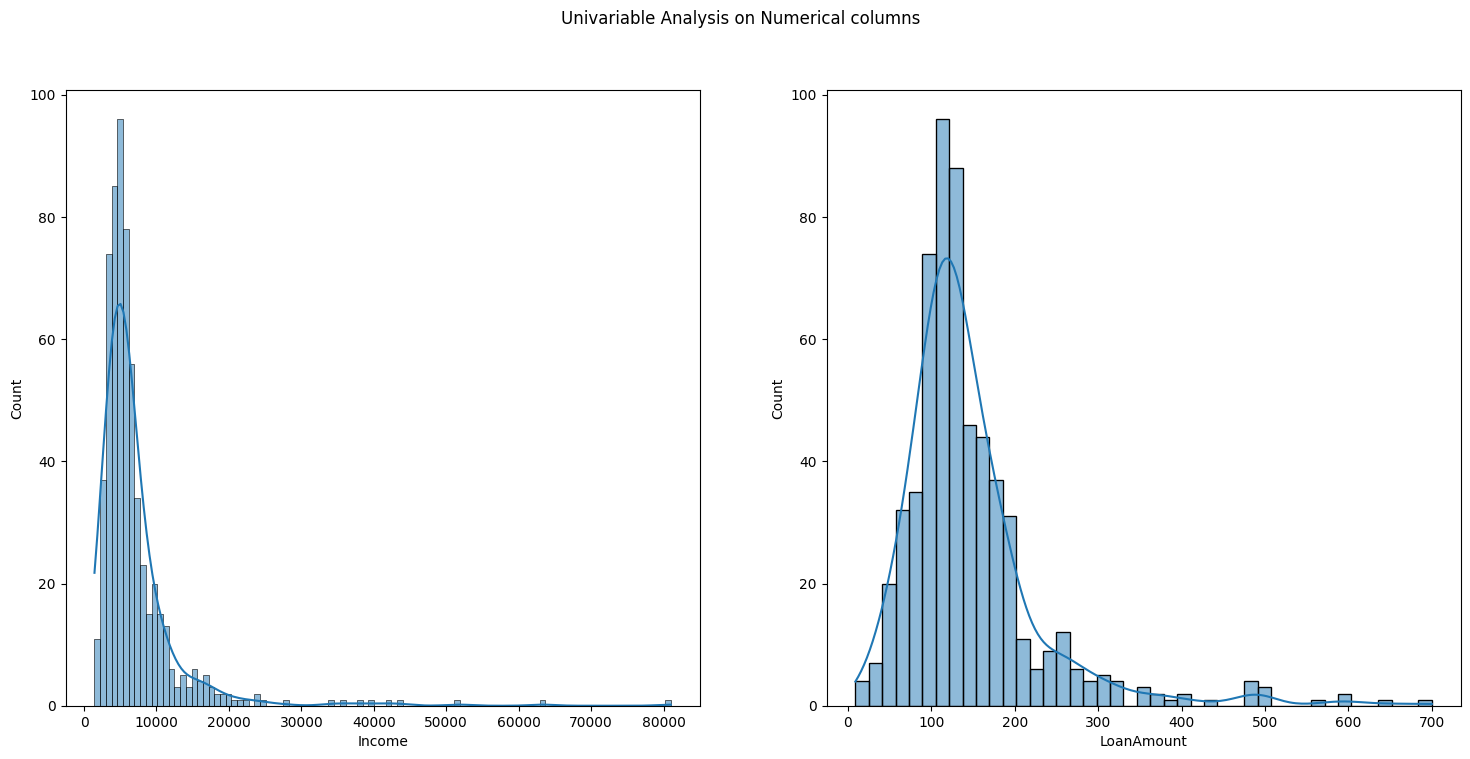

In [189]:
plt.rcParams['figure.figsize'] = (18,8)
plt.subplot(1,2,1)
sns.histplot(data["Income"],kde=True) # Kernel density curve

plt.subplot(1,2,2)
sns.histplot(data["LoanAmount"],kde=True)

plt.suptitle('Univariable Analysis on Numerical columns')
plt.show()

In [190]:
data[continous].skew()

Income        5.633449
LoanAmount    2.677552
dtype: float64

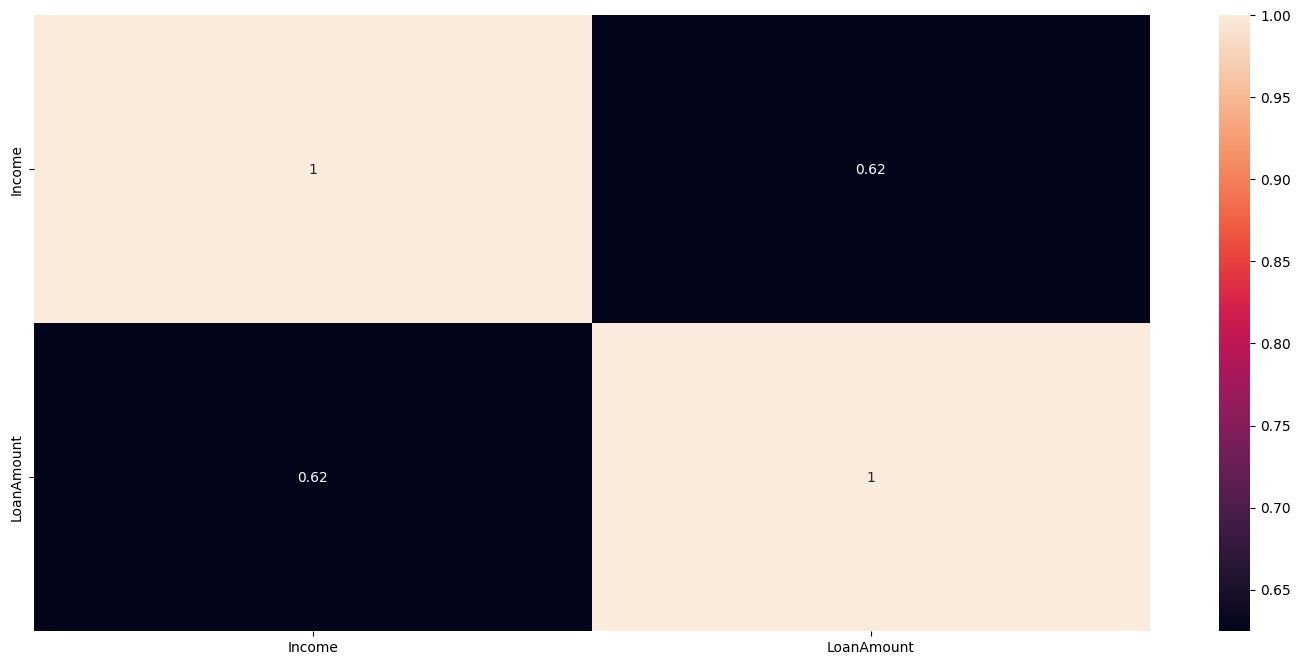

In [191]:
sns.heatmap(data[continous].corr(),annot=True)
plt.show()

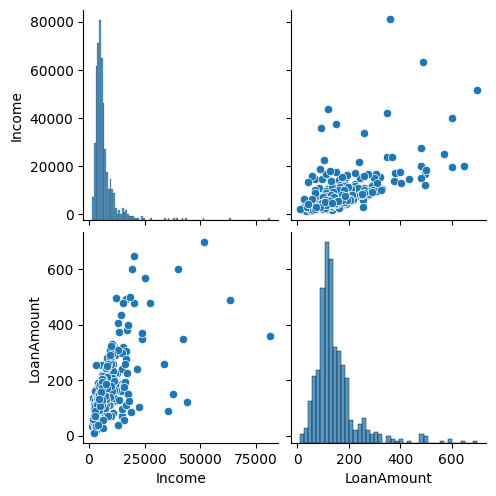

In [192]:
sns.pairplot(data[continous])
plt.show()

**for Discrete Variable**

In [193]:
data[discrete].describe()

,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,601,611,614,582,564,614,614
unique,2,2,2,2,2,3,2
top,Male,Yes,Graduate,No,good,Semiurban,Y
freq,489,398,480,500,475,233,422


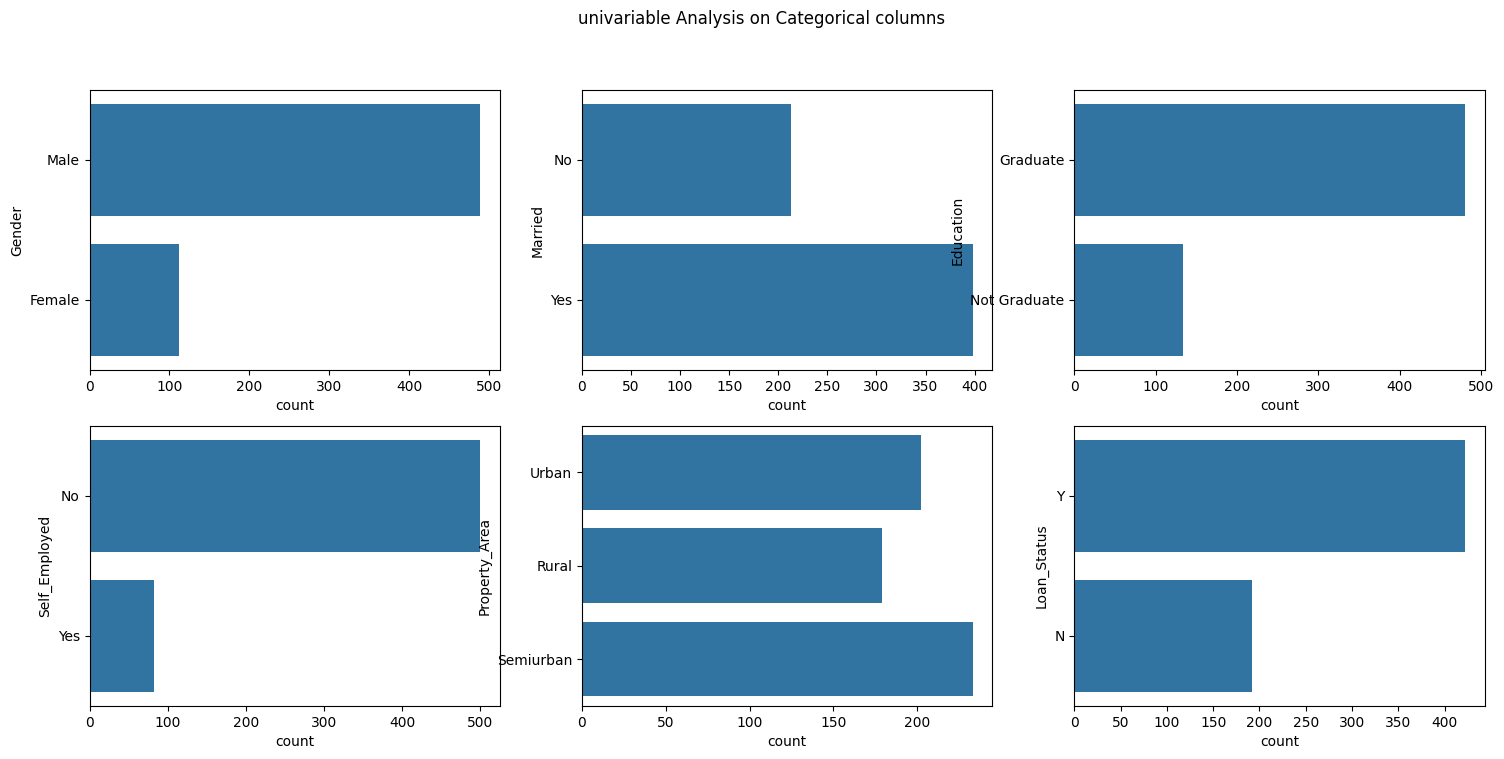

In [194]:
plt.rcParams['figure.figsize'] = (18,8) # dictionary # width,height

plt.subplot(2,3,1)
sns.countplot(data["Gender"])

plt.subplot(2,3,2)
sns.countplot(data["Married"])

plt.subplot(2,3,3)
sns.countplot(data["Education"])

plt.subplot(2,3,4)
sns.countplot(data["Self_Employed"])

plt.subplot(2,3,5)
sns.countplot(data["Property_Area"])

plt.subplot(2,3,6)
sns.countplot(data["Loan_Status"])

plt.suptitle("univariable Analysis on Categorical columns ")
plt.show()

**Lets compare all the categorical with respect to the Loan status to understand the overal**

In [195]:
print(" Impact of marrage on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Married"]))
print("\n")

print(" Impact of Dependents on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Dependents"]))
print("\n")

print(" Impact of Eduaction on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Education"]))
print("\n")

print(" Impact of self_Employed on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Self_Employed"]))
print("\n")

print(" Impact of Area_Property on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Property_Area"]))
print("\n")

print(" Impact of Credit_History on Loan status")
print(pd.crosstab(data["Loan_Status"],data["Credit_History"]))
print("\n")

 Impact of marrage on Loan status
Married       No  Yes
Loan_Status          
N             79  113
Y            134  285


 Impact of Dependents on Loan status
Dependents     0   1   2  3+
Loan_Status                 
N            107  36  25  18
Y            238  66  76  33


 Impact of Eduaction on Loan status
Education    Graduate  Not Graduate
Loan_Status                        
N                 140            52
Y                 340            82


 Impact of self_Employed on Loan status
Self_Employed   No  Yes
Loan_Status            
N              157   26
Y              343   56


 Impact of Area_Property on Loan status
Property_Area  Rural  Semiurban  Urban
Loan_Status                           
N                 69         54     69
Y                110        179    133


 Impact of Credit_History on Loan status
Credit_History  bad  good
Loan_Status              
N                82    97
Y                 7   378




In [196]:
data.isnull().sum()

Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
Income               0
dtype: int64

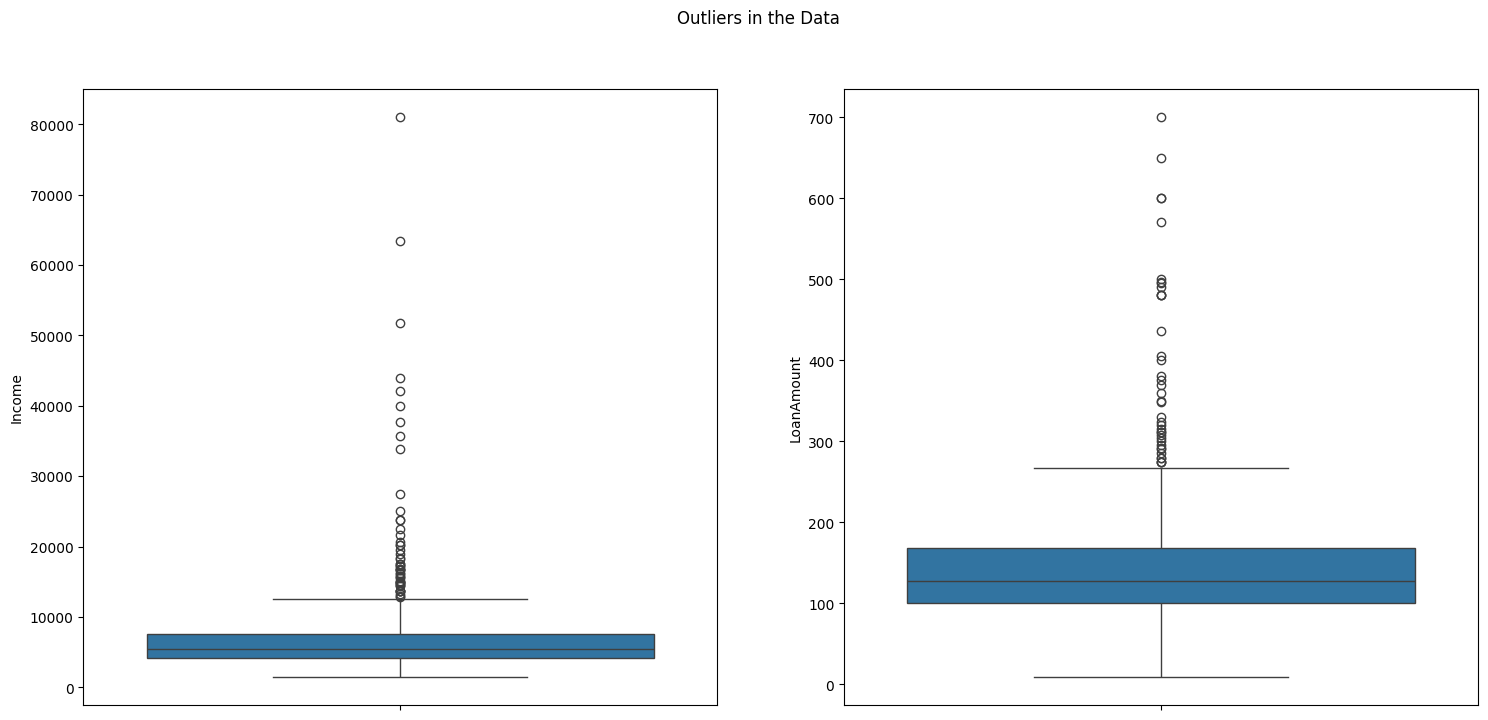

In [197]:
# check outiers

plt.subplot(1,2,1)
sns.boxplot(data["Income"])

plt.subplot(1,2,2)
sns.boxplot(data["LoanAmount"])

plt.suptitle("Outliers in the Data")
plt.show()

# Stage- 3 : Data Preparation


##### 1. Data Cleaning
- Wrong data
- Missing Values
- wrong data types
- Duplicates
- outliers
##### 2. Data wrangling
- Transformation (applicable on continous)
- Scalling (applicable on continous)
- encoding (applicable on categorical)
- **Dont apply any data wrangling technique on count variable**

**Wrong Data treatment**

In [198]:
data["Dependents"]= data["Dependents"].replace({"3+":3})

**Missing Values Treatment**

In [199]:
data['Dependents']= data['Dependents'].fillna(0)

data['Married']= data['Married'].fillna(data['Married'].mode()[0])
data['Gender']= data['Gender'].fillna(data['Gender'].mode()[0])
data['Self_Employed']= data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

data = data.dropna(subset=["Income","LoanAmount","Loan_Amount_Term","Credit_History"])

**Data Type Conversion**

In [200]:
data["Dependents"] = data["Dependents"].astype("int")
data["Loan_Amount_Term"] = data["Loan_Amount_Term"].astype("int")

**Encoding**

In [201]:
data["Gender"] = data["Gender"].replace({"Male":1,"Female":0})
data["Married"] = data["Married"].replace({"Yes":1,"No":0})
data["Education"] = data["Education"].replace({"Graduate":1,"Not Graduate":0})
data["Self_Employed"] = data["Self_Employed"].replace({"Yes":1,"No":0})
data["Property_Area"] = data["Property_Area"].replace({"Rural":0,"Semiurban":1,"Urban":2})
data["Credit_History"] = data["Credit_History"].replace({"good":1,"bad":0})
data["Loan_Status"] = data["Loan_Status"].replace({"Yes":1,"No":0})

**Transformations**

In [202]:
from scipy.stats import boxcox
data["Income"] ,a = boxcox(data["Income"])
data["LoanAmount"] ,b = boxcox(data["LoanAmount"])

In [203]:
data["Loan_Amount_Term"] = data["Loan_Amount_Term"]/12

**Separate x train & y train data**

In [204]:
x = data.drop("Loan_Status",axis=1)
y = data["Loan_Status"]

In [205]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=True)

# Step -4 : Modelling 

In [206]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

## 1 . Logistic Regression

In [207]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

# prediction & Evaulation on train data
ypred_train = log_model.predict(x_train)

print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("Cv Score: ",cross_val_score(log_model,x_train,y_train,scoring="accuracy",cv=5).mean())

# prediction & Evaulation on test data
ypred_test = log_model.predict(x_test)

print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.806146572104019
Cv Score:  0.803781512605042
Test Accuracy:  0.839622641509434


In [208]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,ypred_test))
print(classification_report(y_test,ypred_test))


[[12 17]
 [ 0 77]]
              precision    recall  f1-score   support

           N       1.00      0.41      0.59        29
           Y       0.82      1.00      0.90        77

    accuracy                           0.84       106
   macro avg       0.91      0.71      0.74       106
weighted avg       0.87      0.84      0.81       106



# 2. KNN
- HPT
- Modelling

In [209]:
# Hyperparameter Tuning
estimator = KNeighborsClassifier()
param_grid = {"n_neighbors":list(range(1,50)),"p":[1,2]}
knn_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
knn_hp.fit(x_train,y_train)
knn_hp.best_estimator_

KNeighborsClassifier(n_neighbors=8, p=1)

In [210]:
knn_model = knn_hp.best_estimator_
knn_model.fit(x_train,y_train)

#prediction & Modelling
ypred_train = knn_model.predict(x_train)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(knn_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = knn_model.predict(x_test)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.8037825059101655
CV Score : 0.7493837535014005
Test Accuracy:  0.7358490566037735


## 3 . Svm
- HPT
- modelling

In [211]:
# Hyperparameter Tuning
estimator = SVC()
param_grid = {"C":[0.01,0.1,1],"kernel":["linear","rbf","sigmoid","poly"]}
svm_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
svm_hp.fit(x_train,y_train)
svm_hp.best_estimator_

SVC(C=0.1, kernel='linear')

In [212]:
# Modelling
svm_model = svm_hp.best_estimator_
svm_model.fit(x_train,y_train)

#prediction & Modelling
ypred_train = svm_model.predict(x_train)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(svm_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = svm_model.predict(x_test)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))


Train Accuracy:  0.8085106382978723
CV Score : 0.8084873949579832
Test Accuracy:  0.839622641509434


## 4. Dicision Tress
- HPT
- modelling

In [213]:
# Hyperparameter Tuning
estimator = DecisionTreeClassifier()
param_grid = {"criterion":["gini","entropy"],"max_depth":list(range(1,20))}
dt_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
dt_hp.fit(x_train,y_train)
dt_hp.best_estimator_
dt = dt_hp.best_estimator_

In [214]:
# important feature
feats_dt = pd.DataFrame(data=dt.feature_importances_,index=x.columns,columns=["Importance"])

important_feature = feats_dt[feats_dt["Importance"]>0].index.tolist()
important_feature


['Credit_History']

**Creating Decision Tree model with Importants parameters and Important feature**

In [215]:
#selecting train & Test data
x_train_dt = x_train[important_feature]
x_test_dt = x_test[important_feature]

# Modelling
dt_model = dt_hp.best_estimator_
dt_model.fit(x_train_dt,y_train)

#prediction & Modelling
ypred_train = dt_model.predict(x_train_dt)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(dt_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = dt_model.predict(x_test_dt)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.8085106382978723
CV Score : 0.8084873949579832
Test Accuracy:  0.839622641509434


## 5 . Random Forest
- HPT
- Modelling

In [216]:
# Hyperparameter Tuning
estimator = RandomForestClassifier()
param_grid = {"n_estimators":list(range(1,50))}
rf_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
rf_hp.fit(x_train,y_train)
rf_hp.best_estimator_
rf = rf_hp.best_estimator_

In [217]:
# important feature
feats_rf = pd.DataFrame(data=rf.feature_importances_,index=x.columns,columns=["Importance"])

important_features = feats_rf[feats_dt["Importance"]>0].index.tolist()
important_features

['Credit_History']

In [218]:
#selecting train & Test data
x_train_rf = x_train[important_features]
x_test_rf = x_test[important_features]

# Modelling
rf_model = rf_hp.best_estimator_
rf_model.fit(x_train_rf,y_train)

#prediction & Modelling
ypred_train = rf_model.predict(x_train_rf)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(rf_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = rf_model.predict(x_test_rf)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.8085106382978723
CV Score : 0.7730532212885153
Test Accuracy:  0.839622641509434


## 6 . Ada Boost

In [219]:
# Hyperparameter Tuning
estimator = AdaBoostClassifier()
param_grid = {"n_estimators":list(range(1,50))}
ad_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
ad_hp.fit(x_train,y_train)
ad_hp.best_estimator_
ad = ad_hp.best_estimator_

In [220]:
# important feature
feats_ad = pd.DataFrame(data=ad.feature_importances_,index=x.columns,columns=["Importance"])

important_features = feats_ad[feats_ad["Importance"]>0].index.tolist()
important_features

['Married',
 'Dependents',
 'Education',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Income']

In [221]:
#selecting train & Test data
x_train_ad = x_train[important_features]
x_test_ad = x_test[important_features]

# Modelling
ad_model = ad_hp.best_estimator_
ad_model.fit(x_train_ad,y_train)

#prediction & Modelling
ypred_train = ad_model.predict(x_train_ad)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(ad_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = ad_model.predict(x_test_ad)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.817966903073286
CV Score : 0.8131932773109245
Test Accuracy:  0.8207547169811321


# 7 . Gradient boosting


In [ ]:
# Hyperparameter Tuning
estimator =GradientBoostingClassifier()
param_grid = {"n_estimators":list(range(1,10)),"learning_rate":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}
gb_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")
gb_hp.fit(x_train,y_train)
gb_hp.best_estimator__
gb = gb_hp.best_estimator_

In [223]:
# important feature
feats_gb = pd.DataFrame(data=gb.feature_importances_,index=x.columns,columns=["Importance"])

important_features = feats_gb[feats_gb["Importance"]>0].index.tolist()
important_features

['Married',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Income']

In [224]:
#selecting train & Test data
x_train_gb = x_train[important_features]
x_test_gb = x_test[important_features]

# Modelling
gb_model = gb_hp.best_estimator_
gb_model.fit(x_train_gb,y_train)

#prediction & Modelling
ypred_train = gb_model.predict(x_train_gb)
print("Train Accuracy: ",accuracy_score(y_train,ypred_train))
print("CV Score :",cross_val_score(gb_model,x_train,y_train,cv=5,scoring="accuracy").mean())



# prediction & Evaluation on test data
ypred_test = gb_model.predict(x_test_gb)
print("Test Accuracy: ",accuracy_score(y_test,ypred_test))

Train Accuracy:  0.8226950354609929
CV Score : 0.7989915966386555
Test Accuracy:  0.8301886792452831


In [225]:
from joblib import dump

dump(dt_model,"Loan.joblib")

['Loan.joblib']

# Predict the future data

In [226]:
new_data = {"Loan_ID":"LPO2314",
            "Gender":"Male",
            "Married":"No",
            "Dependents":3,
            "Education":"Graduate",
            "Self_Employed":"Yes",
            "ApplicantIncome":10000,
            "CoapplicantIncome":0,
            "LoanAmount":100,
            "Loan_Amount_Term":240,
            "Credit_History":"good",
            "Property_Area":"Urban"}
            

In [227]:
df = pd.DataFrame(new_data,index=[0])
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LPO2314,Male,No,3,Graduate,Yes,10000,0,100,240,good,Urban


**Apply Preprocessing on Unknow Data**

In [228]:
df.drop(columns=["Loan_ID"],axis = 1,inplace=True)

df["Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.drop(columns=["ApplicantIncome","CoapplicantIncome"])

df["Dependents"] = df["Dependents"].fillna(0)
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df.dropna(subset=["Income","LoanAmount","Loan_Amount_Term","Credit_History"])

df["Dependents"] = df["Dependents"].astype("int")
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("int")

df["Gender"] = df["Gender"].replace({"Male":1,"Female":0})
df["Married"] = df["Married"].replace({"Yes":1,"No":0})
df["Education"] = df["Education"].replace({"Graduate":1,"Not Graduate":0})
df["Self_Employed"] = df["Self_Employed"].replace({"Yes":1,"No":0})
df["Property_Area"] = df["Property_Area"].replace({"Rural":0,"Semiurban":1,"Urban":2})
df["Credit_History"] = df["Credit_History"].replace({"good":1,"bad":0})
df["Loan_Amount_Term"] = df["Loan_Amount_Term"]/12




In [229]:
x_new = df

In [230]:
# import model from joblib 
from joblib import load
model = load("Loan.joblib")

In [231]:
# select important feature for your model
x_new = x_new[important_feature]

# apply & predict your best model
loan = model.predict(x_new)

In [232]:
if loan == "Y":
    print("Eligible for the loan")
else:
    print("Not Eligible for the loan")

Eligible for the loan


In [ ]:
#🔹 Which metric should YOU use for loan approval?

Case 1: Bank wants to avoid losses

👉 Focus on:

Precision
(reduce False Positives)


Case 2: Bank wants more customers

👉 Focus on:

Recall
(reduce False Negatives)

Case 3: Balanced business goal

👉 Use:

F1 Score
AUC for overall performance





🔹 Real-world advice (important)

In loan approval:

False Positive (approve bad customer) = 🔴 worst mistake
False Negative (reject good customer) = 🟡 less severe

👉 So in most real systems:

Precision is prioritized
Then recall is tuned using thresholds